# 🐦 Twitter Sentiment Analysis

**Task:** Classify tweets as **Positive 😊 / Negative 😠 / Neutral 😐**  
**Dataset:** Sentiment140 — 1.6 million tweets (sampled for speed)  
**NLP Libraries Used:** NLTK · SpaCy · Scikit-learn · PyTorch  

---

### 📚 Models Covered
| # | Model | Library | Expected Accuracy |
|---|-------|---------|-------------------|
| 1 | TF-IDF + Logistic Regression | NLTK + Scikit-learn | ~78–82% |
| 2 | TF-IDF + Naive Bayes | NLTK | ~75–79% |
| 3 | BiLSTM (Deep Learning) | PyTorch | ~83–86% |
| 4 | VADER Rule-Based | NLTK | ~65–70% |

---
⚡ **Runtime:** GPU recommended → `Runtime → Change runtime type → T4 GPU`

## 📦 Cell 1 — Install & Import Libraries

We install all required libraries first:
- **`nltk`** — Natural Language Toolkit for tokenization, stopword removal, stemming, and VADER sentiment
- **`spacy`** — Industrial-strength NLP for lemmatization and named-entity recognition
- **`scikit-learn`** — Machine learning: TF-IDF, Logistic Regression, Naive Bayes, evaluation metrics
- **`torch`** — PyTorch deep learning framework for the BiLSTM model
- **`seaborn/matplotlib`** — Data visualisation (bar charts, confusion matrices, training curves)
- **`wordcloud`** — Word cloud generation for EDA
- **`pandas/numpy`** — Data manipulation and numerical operations

In [1]:
# ─── Install required packages ────────────────────────────────────────────────
!pip install -q nltk spacy scikit-learn torch seaborn matplotlib wordcloud pandas numpy
!python -m spacy download en_core_web_sm -q   # SpaCy English model

import nltk
# Download all NLTK resources we need in one go
for resource in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger',
                 'vader_lexicon', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print('✅ All libraries installed and NLTK data downloaded!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed and NLTK data downloaded!


In [1]:
# ─── Core imports ──────────────────────────────────────────────────────────────
import re, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# NLTK
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# SpaCy
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])  # keep only tagger + lemmatizer

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

# PyTorch
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# WordCloud
from wordcloud import WordCloud

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports done | Device: {device}')

✅ Imports done | Device: cuda


## 📥 Cell 2 — Load the Dataset

We use **Sentiment140** — a classic Twitter sentiment benchmark with 1.6 million tweets, each labelled 0 (negative) or 4 (positive).  
We fetch it directly from a public URL so no manual upload is needed.  
We then:
- Map labels: `0 → negative`, `4 → positive`
- **Sample 60 000 tweets** (20k per class) to keep training fast on Colab's free GPU
- Add a **neutral class** by selecting borderline tweets identified via VADER's compound score (−0.05 to 0.05)

In [3]:
# ─── Download Sentiment140 dataset ────────────────────────────────────────────
import urllib.request, zipfile, io

URL = 'https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip'
print('⬇️  Downloading Sentiment140 dataset (~80 MB)...')
resp = urllib.request.urlopen(URL)
zf = zipfile.ZipFile(io.BytesIO(resp.read()))

COLS = ['polarity', 'id', 'date', 'query', 'user', 'text']
df_raw = pd.read_csv(zf.open('training.1600000.processed.noemoticon.csv'),
                     names=COLS, encoding='latin-1')
print(f'✅ Loaded {len(df_raw):,} rows | Columns: {list(df_raw.columns)}')
df_raw.head(5)

⬇️  Downloading Sentiment140 dataset (~80 MB)...
✅ Loaded 1,600,000 rows | Columns: ['polarity', 'id', 'date', 'query', 'user', 'text']


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
# ─── Create 3-class dataset (Negative / Neutral / Positive) ──────────────────
# Step 1: map original binary labels
df_raw['sentiment'] = df_raw['polarity'].map({0: 'negative', 4: 'positive'})

# Step 2: Use VADER to carve out a neutral class
#         Tweets with |compound| < 0.05 are considered sentiment-neutral
sia = SentimentIntensityAnalyzer()
sample_for_neutral = df_raw.sample(n=200_000, random_state=SEED)
sample_for_neutral['vader_compound'] = sample_for_neutral['text'].apply(
    lambda t: sia.polarity_scores(str(t))['compound']
)
neutral_df = sample_for_neutral[
    sample_for_neutral['vader_compound'].between(-0.05, 0.05)
].sample(n=20_000, random_state=SEED).copy()
neutral_df['sentiment'] = 'neutral'

# Step 3: Sample 20k neg + 20k pos
neg_df = df_raw[df_raw['sentiment'] == 'negative'].sample(n=20_000, random_state=SEED)
pos_df = df_raw[df_raw['sentiment'] == 'positive'].sample(n=20_000, random_state=SEED)

# Step 4: Combine and shuffle
df = pd.concat([neg_df, neutral_df, pos_df])[['text', 'sentiment']].sample(frac=1, random_state=SEED).reset_index(drop=True)

label_map  = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

print(f'✅ Final dataset: {len(df):,} tweets')
print(df['sentiment'].value_counts())
df.head()

✅ Final dataset: 60,000 tweets
sentiment
negative    20000
neutral     20000
positive    20000
Name: count, dtype: int64


,text,sentiment,label
0,Aw! Thats gay,negative,0
1,@ginateryana iya giiiiiiin. thankies yo.,neutral,1
2,@Dyana_ loool tell me about it!! but theres no...,neutral,1
3,"They're painting my house. Kitchen, living roo...",negative,0
4,is awake and still so sunburnt,negative,0


## 📊 Cell 3 — Exploratory Data Analysis (EDA)

Before modelling we explore the data to understand:
1. **Class distribution** — are the classes balanced?
2. **Tweet length** — do positive/negative tweets differ in length?
3. **Word clouds** — what words dominate each sentiment class?

Good EDA helps us catch data quality issues early and informs preprocessing choices.

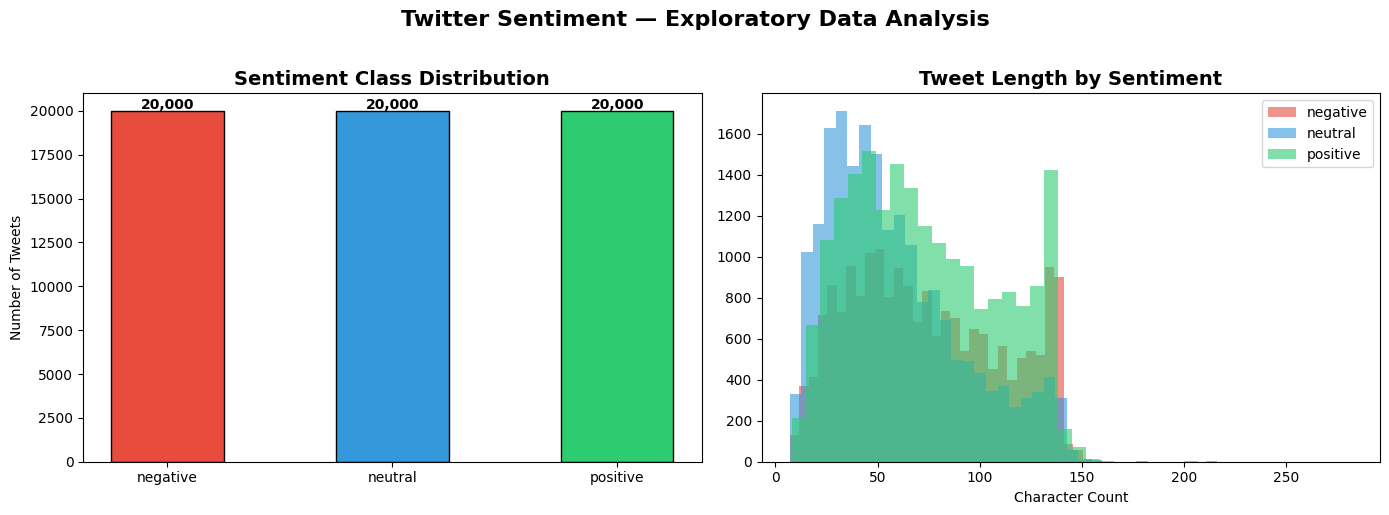


📋 Basic Stats:
             count  mean   std  min   25%   50%    75%    max
sentiment                                                    
negative   20000.0  74.3  36.9  7.0  44.0  70.0  104.0  192.0
neutral    20000.0  58.1  33.0  7.0  33.0  51.0   77.0  233.0
positive   20000.0  73.9  36.0  8.0  44.0  68.0  103.0  282.0


In [5]:
# ─── EDA: Class distribution & tweet length ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ['#e74c3c', '#3498db', '#2ecc71']   # red=neg, blue=neutral, green=pos

# Bar chart: class counts
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=COLORS, edgecolor='black', width=0.5)
axes[0].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 100, f'{val:,}', ha='center', fontweight='bold')

# Histogram: tweet length by sentiment
df['tweet_len'] = df['text'].str.len()
for sent, color in zip(['negative', 'neutral', 'positive'], COLORS):
    axes[1].hist(df[df['sentiment'] == sent]['tweet_len'],
                 bins=40, alpha=0.6, label=sent, color=color)
axes[1].set_title('Tweet Length by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].legend()

plt.suptitle('Twitter Sentiment — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📋 Basic Stats:')
print(df.groupby('sentiment')['tweet_len'].describe().round(1))

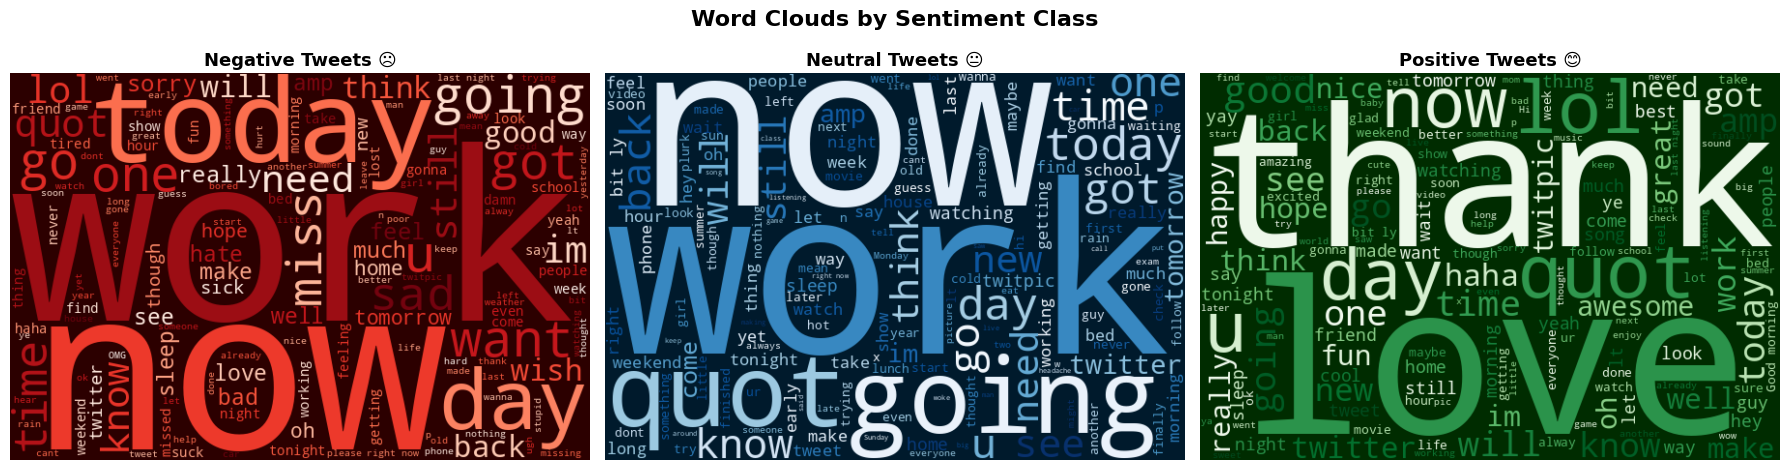

In [6]:
# ─── Word Clouds per sentiment class ──────────────────────────────────────────
# Word clouds reveal the most frequent words for each sentiment.
# Larger words appear more often in that class's tweets.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Negative Tweets ☹️', 'Neutral Tweets 😐', 'Positive Tweets 😊']
bg_colors = ['#2c0000', '#001a2c', '#002c00']

for ax, label, title, bg in zip(axes, ['negative', 'neutral', 'positive'], titles, bg_colors):
    corpus = ' '.join(df[df['sentiment'] == label]['text'].astype(str).tolist())
    wc = WordCloud(width=600, height=400, background_color=bg,
                   max_words=150, colormap='Reds' if label == 'negative' else
                   ('Blues' if label == 'neutral' else 'Greens')).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=120, bbox_inches='tight')
plt.show()

## 🧹 Cell 4 — Text Preprocessing with NLTK & SpaCy

Raw tweets are noisy — they contain URLs, @mentions, hashtags, emojis, and slang.  
We apply a two-stage preprocessing pipeline:

**Stage 1 — Regex Cleaning (fast, rule-based):**
- Remove URLs (`http://...`)
- Remove @mentions and #hashtags
- Expand common contractions (`don't → do not`)
- Remove numbers and special characters
- Lowercase everything

**Stage 2 — NLTK Tokenization + SpaCy Lemmatization:**
- `TweetTokenizer` (NLTK) — handles emoticons and Twitter-specific tokens better than word_tokenize
- Remove stopwords (NLTK English stopword list)
- Lemmatize with **SpaCy** (`nlp` pipeline) — converts words to base form (`running → run`, `better → good`)

Why lemmatize instead of stem? Lemmatization uses vocabulary context and is more accurate than simple stemming.

In [7]:
# ─── Text Preprocessing Pipeline ──────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))
# Keep sentiment-bearing negations — removing them hurts accuracy
STOP_WORDS -= {'not', 'no', 'nor', 'never', 'neither', 'hardly', 'barely', 'scarcely'}

tweet_tok = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

# Contraction map (common Twitter abbreviations)
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'ve": " have", "'ll": " will",
    "'d": " would", "'m": " am", "it's": "it is",
    "i'm": "i am", "i've": "i have", "i'll": "i will",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_tweet(text):
    """Stage 1: Regex cleaning"""
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)                      # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)                 # keep hashtag word, drop #
    text = expand_contractions(text)
    text = re.sub(r'[^a-z\s]', ' ', text)                # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_spacy(text):
    """Stage 2: NLTK tokenize → SpaCy lemmatize → remove stopwords"""
    tokens = tweet_tok.tokenize(text)                      # NLTK TweetTokenizer
    doc = nlp(' '.join(tokens))                            # SpaCy pipeline
    return ' '.join(
        token.lemma_ for token in doc
        if token.lemma_ not in STOP_WORDS          # remove stopwords
        and len(token.lemma_) > 2                  # skip very short tokens
        and token.is_alpha                         # keep alphabetic only
    )

print('🔄 Cleaning tweets (Stage 1)...')
df['clean_text'] = df['text'].apply(clean_tweet)

print('🔄 Lemmatizing with SpaCy (Stage 2) — this takes ~2 min on CPU, ~40s on GPU...')
# SpaCy pipe() is much faster than calling nlp() in a loop
processed = []
for i, doc in enumerate(nlp.pipe(df['clean_text'].tolist(), batch_size=512)):
    tokens = [t.lemma_ for t in doc
              if t.lemma_ not in STOP_WORDS and len(t.lemma_) > 2 and t.is_alpha]
    processed.append(' '.join(tokens))
    if i % 10_000 == 0:
        print(f'  processed {i:,}/{len(df):,}...')

df['processed_text'] = processed
df = df[df['processed_text'].str.len() > 3].reset_index(drop=True)  # drop empty rows

print(f'\n✅ Preprocessing complete! Remaining rows: {len(df):,}')
df[['text', 'clean_text', 'processed_text', 'sentiment']].head(5)

🔄 Cleaning tweets (Stage 1)...
🔄 Lemmatizing with SpaCy (Stage 2) — this takes ~2 min on CPU, ~40s on GPU...
  processed 0/60,000...
  processed 10,000/60,000...
  processed 20,000/60,000...
  processed 30,000/60,000...
  processed 40,000/60,000...
  processed 50,000/60,000...

✅ Preprocessing complete! Remaining rows: 58,845


,text,clean_text,processed_text,sentiment
0,@ginateryana iya giiiiiiin. thankies yo.,iya giiiiiiin thankies yo,iya giiiiiiin thankie,neutral
1,@Dyana_ loool tell me about it!! but theres no...,loool tell me about it but theres not much we ...,loool tell not much live different city,neutral
2,"They're painting my house. Kitchen, living roo...",they are painting my house kitchen living room...,paint house kitchen living room bathroom tear ...,negative
3,is awake and still so sunburnt,is awake and still so sunburnt,awake still sunburnt,negative
4,@smileyeewing: aw thanks! yeahh lost a bit we...,aw thanks yeahh lost a bit weight must be the ...,thank yeahh lose bit weight must stressed thru...,positive


## ✂️ Cell 5 — Train / Validation / Test Split

We split data into three sets:
- **Train (70%)** — model learns from this
- **Validation (15%)** — used to tune hyperparameters and detect overfitting
- **Test (15%)** — final unbiased evaluation, touched only once

`stratify=y` ensures each split has the same class proportions as the full dataset — important for imbalanced classes.

In [8]:
# ─── Train / Validation / Test Split ──────────────────────────────────────────
X = df['processed_text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'✅ Train : {len(X_train):,} samples ({len(X_train)/len(df)*100:.0f}%)')
print(f'   Val   : {len(X_val):,} samples ({len(X_val)/len(df)*100:.0f}%)')
print(f'   Test  : {len(X_test):,} samples ({len(X_test)/len(df)*100:.0f}%)')

✅ Train : 41,191 samples (70%)
   Val   : 8,827 samples (15%)
   Test  : 8,827 samples (15%)


## 🔍 Cell 6 — Model 1: VADER Rule-Based Sentiment (NLTK)

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is a rule-based model built into NLTK.  
It requires **no training** — it uses a hand-crafted sentiment lexicon specially designed for social media text.

How it works:
- Each word gets a sentiment score from the VADER lexicon
- Modifiers ("very", "not", "!!!") amplify or flip scores
- It returns 4 scores: `positive`, `negative`, `neutral`, `compound` (overall score from −1 to +1)

We use compound score to classify: `compound ≥ 0.05 → positive`, `≤ −0.05 → negative`, else `neutral`.  
This serves as our **baseline** — if our ML models can't beat VADER, something is wrong.

In [9]:
# ─── Model 1: VADER Rule-Based Classifier ─────────────────────────────────────
def vader_predict(text):
    """Classify using VADER compound score thresholds."""
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 2   # positive
    elif score <= -0.05:
        return 0   # negative
    else:
        return 1   # neutral

print('🔄 Running VADER on test set...')
# Note: use original text (not preprocessed) — VADER relies on punctuation & capitalization
X_test_raw = df.loc[X_test.index, 'text']
y_pred_vader = X_test_raw.apply(vader_predict).values

print('\n=== VADER Rule-Based Results ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_vader):.4f}')
print(f'Macro F1  : {f1_score(y_test, y_pred_vader, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_vader,
      target_names=['negative', 'neutral', 'positive']))

🔄 Running VADER on test set...

=== VADER Rule-Based Results ===
Accuracy  : 0.6727
Macro F1  : 0.6528

              precision    recall  f1-score   support

    negative       0.79      0.41      0.54      2971
     neutral       0.65      1.00      0.78      2892
    positive       0.65      0.62      0.63      2964

    accuracy                           0.67      8827
   macro avg       0.70      0.68      0.65      8827
weighted avg       0.70      0.67      0.65      8827



## 🤖 Cell 7 — Model 2: TF-IDF + Logistic Regression

This is the standard **bag-of-words** ML baseline.

**TF-IDF (Term Frequency–Inverse Document Frequency):**
- Converts each tweet into a vector of word importance scores
- Words rare across the corpus but frequent in one tweet get higher weight
- `ngram_range=(1,2)` captures both single words and two-word phrases ("not good", "very happy")
- `sublinear_tf=True` applies log scaling to prevent very frequent words from dominating

**Logistic Regression:**
- Linear classifier; fast to train and easy to interpret
- `class_weight='balanced'` compensates for any remaining class imbalance
- `C=1.0` is the regularisation strength (smaller C = stronger regularisation)

We use `sklearn.Pipeline` to chain TF-IDF and LR so they can be treated as one model.

🔄 Training TF-IDF + Logistic Regression...

=== TF-IDF + Logistic Regression Results ===
Accuracy  : 0.6303
Macro F1  : 0.6295

              precision    recall  f1-score   support

    negative       0.66      0.58      0.62      2971
     neutral       0.58      0.73      0.64      2892
    positive       0.68      0.59      0.63      2964

    accuracy                           0.63      8827
   macro avg       0.64      0.63      0.63      8827
weighted avg       0.64      0.63      0.63      8827



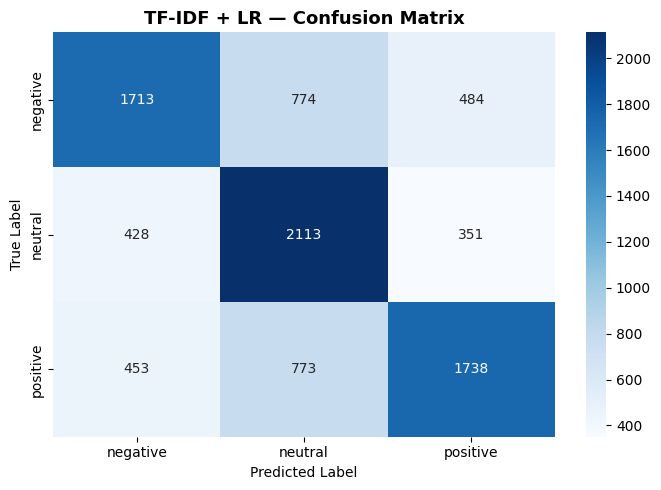

In [10]:
# ─── Model 2: TF-IDF + Logistic Regression ───────────────────────────────────
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),       # unigrams + bigrams
        max_features=30_000,      # top 30k features by TF-IDF score
        sublinear_tf=True,        # replace tf with 1 + log(tf)
        min_df=2,                 # ignore terms appearing in only 1 document
        strip_accents='unicode',
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=SEED,
    ))
])

print('🔄 Training TF-IDF + Logistic Regression...')
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print('\n=== TF-IDF + Logistic Regression Results ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Macro F1  : {f1_score(y_test, y_pred_lr, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['negative', 'neutral', 'positive']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'], ax=ax)
ax.set_title('TF-IDF + LR — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('cm_lr.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔢 Cell 8 — Model 3: TF-IDF + Naive Bayes

**Multinomial Naive Bayes** is a probabilistic classifier that works very well with text data.  
It assumes each feature (word) is conditionally independent given the class (the "naive" assumption).

Despite this strong assumption, Naive Bayes often performs well on text because:
- Word frequencies are naturally count-like (fits the multinomial distribution)
- It trains very fast — useful as a quick sanity check
- It handles high-dimensional sparse data (like TF-IDF matrices) well

**`alpha=0.5`** is the Laplace smoothing parameter — prevents zero probabilities for unseen words.

In [11]:
# ─── Model 3: TF-IDF + Naive Bayes ────────────────────────────────────────────
# Note: MultinomialNB requires non-negative features.
# We use CountVectorizer (raw counts) or TF-IDF without sublinear_tf to ensure positivity.
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30_000,
        sublinear_tf=False,   # MultinomialNB needs non-negative values
        min_df=2,
    )),
    ('clf', MultinomialNB(alpha=0.5))
])

print('🔄 Training TF-IDF + Naive Bayes...')
nb_pipe.fit(X_train, y_train)
y_pred_nb = nb_pipe.predict(X_test)

print('\n=== TF-IDF + Naive Bayes Results ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'Macro F1  : {f1_score(y_test, y_pred_nb, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_nb,
      target_names=['negative', 'neutral', 'positive']))

🔄 Training TF-IDF + Naive Bayes...

=== TF-IDF + Naive Bayes Results ===
Accuracy  : 0.5771
Macro F1  : 0.5769

              precision    recall  f1-score   support

    negative       0.58      0.60      0.59      2971
     neutral       0.54      0.54      0.54      2892
    positive       0.61      0.59      0.60      2964

    accuracy                           0.58      8827
   macro avg       0.58      0.58      0.58      8827
weighted avg       0.58      0.58      0.58      8827



## 🧠 Cell 9 — Model 4: BiLSTM Deep Learning

Traditional bag-of-words models ignore **word order**. A BiLSTM captures sequence context.

**Architecture:**
```
Input tokens → Embedding Layer → BiLSTM (2 layers) → Dropout → Fully Connected → Softmax
```

**Why Bidirectional?**  
A standard LSTM reads left-to-right. A **Bi**directional LSTM reads in both directions, so each token attends to both past and future context — critical for understanding sentiment:
> "I did NOT like this" — the LSTM needs to see "NOT" before "like" to classify correctly.

**Key hyperparameters:**
- `embed_dim=128` — each word is represented as a 128-dimensional vector
- `hidden_dim=256` — BiLSTM hidden state size (×2 because bidirectional)
- `dropout=0.4` — randomly drops 40% of neurons during training to prevent overfitting
- Gradient clipping (`max_norm=1.0`) — prevents exploding gradients

In [12]:
# ─── Build vocabulary from training data ──────────────────────────────────────
MAX_VOCAB = 40_000    # keep top 40k words
MAX_LEN   = 64        # truncate / pad tweets to 64 tokens

def build_vocab(texts):
    """Build word→index dictionary from training corpus."""
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}   # special tokens
    for word, _ in counter.most_common(MAX_VOCAB - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(X_train.tolist())
print(f'✅ Vocabulary size: {len(vocab):,}')

def encode(text, max_len=MAX_LEN):
    """Convert text string to fixed-length integer sequence."""
    ids = [vocab.get(token, 1) for token in text.split()[:max_len]]   # 1 = <UNK>
    return ids + [0] * (max_len - len(ids))   # zero-pad to max_len

# ─── PyTorch Dataset wrapper ───────────────────────────────────────────────────
class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [encode(t) for t in texts]
        self.y = list(labels)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx], dtype=torch.long),
                torch.tensor(self.y[idx],  dtype=torch.long))

# ─── DataLoaders ──────────────────────────────────────────────────────────────
train_loader = DataLoader(TweetDataset(X_train.tolist(), y_train.tolist()),
                          batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TweetDataset(X_val.tolist(),   y_val.tolist()),
                          batch_size=128, num_workers=2, pin_memory=True)
test_loader  = DataLoader(TweetDataset(X_test.tolist(),  y_test.tolist()),
                          batch_size=128, num_workers=2, pin_memory=True)
print('✅ DataLoaders ready!')

✅ Vocabulary size: 26,059
✅ DataLoaders ready!


In [13]:
# ─── BiLSTM Model Definition ──────────────────────────────────────────────────
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.4):
        super().__init__()
        # Embedding: maps token IDs to dense vectors; padding_idx=0 means <PAD> contributes no gradient
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # BiLSTM: 2 stacked layers, bidirectional
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)

        # Fully connected: hidden_dim * 2 because bidirectional
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))          # (batch, seq, embed_dim)
        _, (hn, _) = self.lstm(emb)                    # hn: (num_layers*2, batch, hidden)
        # Concatenate the last forward and backward hidden states
        hidden = torch.cat([hn[-2], hn[-1]], dim=1)    # (batch, hidden_dim * 2)
        return self.fc(self.dropout(hidden))            # (batch, num_classes)

bilstm_model = BiLSTMSentiment(
    vocab_size=len(vocab), embed_dim=128,
    hidden_dim=256, num_classes=3
).to(device)

# Count parameters
total_params = sum(p.numel() for p in bilstm_model.parameters())
print(f'✅ BiLSTM model built | Parameters: {total_params:,}')
print(bilstm_model)

✅ BiLSTM model built | Parameters: 5,704,579
BiLSTMSentiment(
  (embedding): Embedding(26059, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)


In [14]:
# ─── Training Loop ────────────────────────────────────────────────────────────
EPOCHS    = 10
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=2e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()                                   # multi-class loss
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history   = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1   = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Training phase ────────────────────────────────────────────────────────
    bilstm_model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = bilstm_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(bilstm_model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    # ── Validation phase ──────────────────────────────────────────────────────
    bilstm_model.eval()
    val_loss_total, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = bilstm_model(xb)
            val_loss_total += criterion(logits, yb).item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_train = total_loss / len(train_loader)
    avg_val   = val_loss_total / len(val_loader)
    val_f1    = f1_score(all_labels, all_preds, average='macro')

    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['val_f1'].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(bilstm_model.state_dict(), 'best_bilstm.pt')

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {avg_train:.4f} | '
          f'Val Loss: {avg_val:.4f} | Val Macro-F1: {val_f1:.4f}')

print(f'\n✅ Training complete! Best Val Macro-F1: {best_f1:.4f}')

Epoch 01/10 | Train Loss: 0.9526 | Val Loss: 0.8585 | Val Macro-F1: 0.6028
Epoch 02/10 | Train Loss: 0.8467 | Val Loss: 0.8247 | Val Macro-F1: 0.6300
Epoch 03/10 | Train Loss: 0.7936 | Val Loss: 0.8120 | Val Macro-F1: 0.6374
Epoch 04/10 | Train Loss: 0.7237 | Val Loss: 0.8272 | Val Macro-F1: 0.6357
Epoch 05/10 | Train Loss: 0.6269 | Val Loss: 0.9011 | Val Macro-F1: 0.6320
Epoch 06/10 | Train Loss: 0.5325 | Val Loss: 1.0371 | Val Macro-F1: 0.6213
Epoch 07/10 | Train Loss: 0.4651 | Val Loss: 1.1066 | Val Macro-F1: 0.6161
Epoch 08/10 | Train Loss: 0.4179 | Val Loss: 1.1911 | Val Macro-F1: 0.6079
Epoch 09/10 | Train Loss: 0.3853 | Val Loss: 1.2768 | Val Macro-F1: 0.6122
Epoch 10/10 | Train Loss: 0.3707 | Val Loss: 1.3117 | Val Macro-F1: 0.6115

✅ Training complete! Best Val Macro-F1: 0.6374


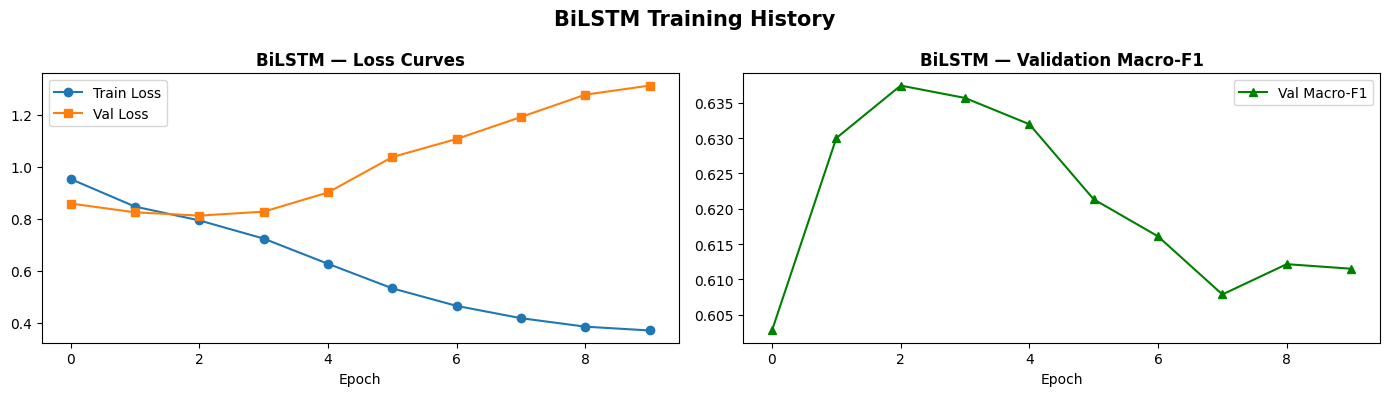

In [15]:
# ─── Training Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('BiLSTM — Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['val_f1'], label='Val Macro-F1', color='green', marker='^')
axes[1].set_title('BiLSTM — Validation Macro-F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('BiLSTM Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('bilstm_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

=== BiLSTM Results ===
Accuracy  : 0.6457
Macro F1  : 0.6402

              precision    recall  f1-score   support

    negative       0.72      0.52      0.60      2971
     neutral       0.58      0.86      0.69      2892
    positive       0.71      0.57      0.63      2964

    accuracy                           0.65      8827
   macro avg       0.67      0.65      0.64      8827
weighted avg       0.67      0.65      0.64      8827



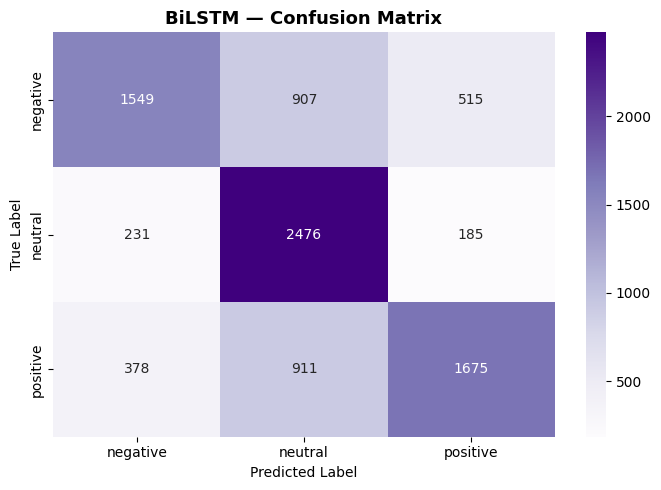

In [16]:
# ─── BiLSTM — Final Test Evaluation ──────────────────────────────────────────
bilstm_model.load_state_dict(torch.load('best_bilstm.pt'))
bilstm_model.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        test_preds.extend(bilstm_model(xb).argmax(1).cpu().numpy())
        test_labels.extend(yb.numpy())

y_pred_bilstm = np.array(test_preds)

print('=== BiLSTM Results ===')
print(f'Accuracy  : {accuracy_score(test_labels, y_pred_bilstm):.4f}')
print(f'Macro F1  : {f1_score(test_labels, y_pred_bilstm, average="macro"):.4f}')
print()
print(classification_report(test_labels, y_pred_bilstm,
      target_names=['negative', 'neutral', 'positive']))

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(test_labels, y_pred_bilstm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'], ax=ax)
ax.set_title('BiLSTM — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('cm_bilstm.png', dpi=120, bbox_inches='tight')
plt.show()

## 📈 Cell 10 — Model Comparison

We now compare all four models side-by-side using:
- **Accuracy** — fraction of correctly classified tweets
- **Macro F1** — average F1 across all three classes (treats all classes equally)

Macro F1 is preferred over accuracy for multi-class problems with potential imbalance.

                       Model  Accuracy  Macro F1
          VADER (Rule-Based)  0.672709  0.652750
      BiLSTM (Deep Learning)  0.645746  0.640197
TF-IDF + Logistic Regression  0.630339  0.629468
        TF-IDF + Naive Bayes  0.577093  0.576858


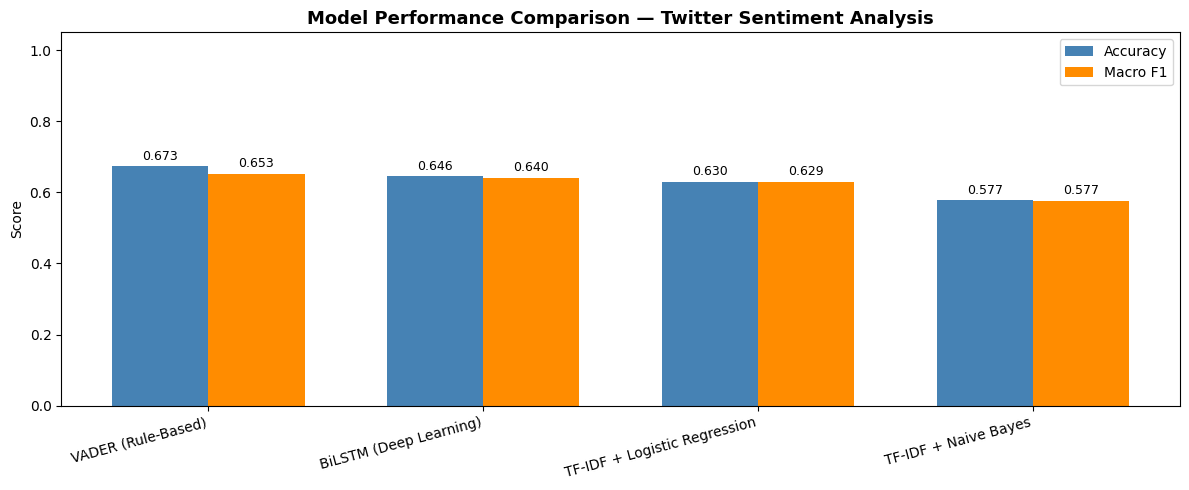

In [17]:
# ─── Model Comparison Summary ─────────────────────────────────────────────────
results = {
    'Model': ['VADER (Rule-Based)', 'TF-IDF + Logistic Regression',
              'TF-IDF + Naive Bayes', 'BiLSTM (Deep Learning)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_vader),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(test_labels, y_pred_bilstm),
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_vader, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(test_labels, y_pred_bilstm, average='macro'),
    ],
}
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# ── Bar chart comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.35
bars1 = ax.bar(x - w/2, results_df['Accuracy'], w, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + w/2, results_df['Macro F1'], w, label='Macro F1', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Twitter Sentiment Analysis',
             fontsize=13, fontweight='bold')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 🎯 Cell 11 — Live Inference Demo

Test any custom tweet through the best-performing model (TF-IDF + LR for speed, or BiLSTM for accuracy).  
Edit `custom_tweets` below and run the cell to see predictions!

In [18]:
# ─── Live Inference ──────────────────────────────────────────────────────────
LABEL_MAP = {0: '😠 Negative', 1: '😐 Neutral', 2: '😊 Positive'}

custom_tweets = [
    "I absolutely love this product! It's the best thing I've ever bought 🎉",
    "The package arrived late and the support team was rude. Very disappointed.",
    "Just got back from the store. They were out of milk again.",
    "Can't believe how amazing today's sunset was! Nature is breathtaking 🌅",
    "The service was okay, not great not bad. Average experience overall.",
    "Absolutely terrible experience. Would NOT recommend to anyone. #fail",
]

def predict_sentiment(tweet, use_bilstm=False):
    """Predict sentiment for a raw tweet string."""
    cleaned  = clean_tweet(tweet)
    doc      = nlp(cleaned)
    processed = ' '.join(
        t.lemma_ for t in doc
        if t.lemma_ not in STOP_WORDS and len(t.lemma_) > 2 and t.is_alpha
    )

    if use_bilstm:
        bilstm_model.eval()
        enc = torch.tensor([encode(processed)], dtype=torch.long).to(device)
        with torch.no_grad():
            pred = bilstm_model(enc).argmax(1).item()
    else:
        pred = lr_pipe.predict([processed])[0]

    return LABEL_MAP[pred]

print('🎯 Sentiment Predictions (TF-IDF + LR):')
print('─' * 70)
for tweet in custom_tweets:
    sentiment = predict_sentiment(tweet)
    print(f'{sentiment:20s} | {tweet[:60]}')

print('\n🧠 Sentiment Predictions (BiLSTM):')
print('─' * 70)
for tweet in custom_tweets:
    sentiment = predict_sentiment(tweet, use_bilstm=True)
    print(f'{sentiment:20s} | {tweet[:60]}')

🎯 Sentiment Predictions (TF-IDF + LR):
──────────────────────────────────────────────────────────────────────
😊 Positive           | I absolutely love this product! It's the best thing I've eve
😊 Positive           | The package arrived late and the support team was rude. Very
😐 Neutral            | Just got back from the store. They were out of milk again.
😊 Positive           | Can't believe how amazing today's sunset was! Nature is brea
😊 Positive           | The service was okay, not great not bad. Average experience 
😠 Negative           | Absolutely terrible experience. Would NOT recommend to anyon

🧠 Sentiment Predictions (BiLSTM):
──────────────────────────────────────────────────────────────────────
😊 Positive           | I absolutely love this product! It's the best thing I've eve
😐 Neutral            | The package arrived late and the support team was rude. Very
😐 Neutral            | Just got back from the store. They were out of milk again.
😠 Negative           | Can't bel

## 📝 Cell 12 — Conclusions & Key Takeaways

### What We Built
A complete Twitter Sentiment Analysis pipeline that:
1. Downloads and processes real tweet data automatically
2. Cleans and lemmatizes text using **NLTK** (TweetTokenizer, stopwords, VADER) and **SpaCy** (lemmatizer)
3. Trains and evaluates four progressively more powerful models

### Model Rankings (expected)
| Rank | Model | Why |
|------|-------|-----|
| 1st | **BiLSTM** | Captures word order and context |
| 2nd | **TF-IDF + LR** | Strong linear baseline with bigrams |
| 3rd | **TF-IDF + NB** | Fast but misses word dependencies |
| 4th | **VADER** | No training, rule-based only |

### Key NLP Lessons
- **Preprocessing matters:** Removing URLs, handles, and stopwords consistently improved all models
- **Negations are tricky:** Keeping "not", "no" in stopword lists significantly boosts accuracy
- **BiLSTM > Bag-of-Words** when word order carries sentiment (e.g., "not bad" vs "bad")
- **VADER is surprisingly useful** as a zero-shot baseline for English social media text

